In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.float_format', lambda x:'%.3f' % x)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set(style='ticks')
sns.set_palette('Paired')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f"현재 작업 디렉토리 : {os.getcwd()}")

현재 작업 디렉토리 : C:\Users\pang\Desktop\데이터 분석가\주제2.소규모 태양광 발전소를 운영하는 사업자들의 어려움\data


In [3]:
df = pd.read_csv('Renewable.csv')
df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.000,1.600,1021,100,4.900,0.000,0.000,100,0,0,450,0.000,4,0,1
1,2017-01-01 00:15:00,0,0.000,1.600,1021,100,4.900,0.000,0.000,100,0,0,450,0.000,4,0,1
2,2017-01-01 00:30:00,0,0.000,1.600,1021,100,4.900,0.000,0.000,100,0,0,450,0.000,4,0,1
3,2017-01-01 00:45:00,0,0.000,1.600,1021,100,4.900,0.000,0.000,100,0,0,450,0.000,4,0,1
4,2017-01-01 01:00:00,0,0.000,1.700,1020,100,5.200,0.000,0.000,100,0,0,450,0.000,4,1,1


## 데이터 구조 파악 & 품질 점검

In [4]:
# 데이터 크기 확인
df.shape

(196776, 17)

In [5]:
# 데이터 갯수, null 유무확인, 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

- 결측치는 없음

In [6]:
# 중복 데이터 검사
print(df.duplicated().sum())

0


- 중복되는 행은 없음(행 전체데이터가 중복되는 것이 없다는 말!)

In [7]:
# 각 컬럼별 고유값 개수 확인
print(df.nunique())

Time                      196776
Energy delta[Wh]            4556
GHI                         2277
temp                         503
pressure                      71
humidity                      79
wind_speed                   136
rain_1h                      311
snow_1h                      129
clouds_all                   101
isSun                          2
sunlightTime                  69
dayLength                     39
SunlightTime/daylength       101
weather_type                   5
hour                          24
month                         12
dtype: int64


- 수치형 데이터 or 범주형 데이터 확인하기 위해

#### 데이터 세트 내 수치형(Numerical) 컬럼들의 주요 특징을 한눈에 파악하기 위해 계산되는 요약 정보

In [8]:
# 데이터 요약 정리
print(df.describe().transpose())

                            count     mean      std     min      25%      50%  \
Energy delta[Wh]       196776.000  573.008 1044.824   0.000    0.000    0.000   
GHI                    196776.000   32.597   52.172   0.000    0.000    1.600   
temp                   196776.000    9.791    7.995 -16.600    3.600    9.300   
pressure               196776.000 1015.293    9.586 977.000 1010.000 1016.000   
humidity               196776.000   79.811   15.604  22.000   70.000   84.000   
wind_speed             196776.000    3.938    1.822   0.000    2.600    3.700   
rain_1h                196776.000    0.066    0.279   0.000    0.000    0.000   
snow_1h                196776.000    0.007    0.070   0.000    0.000    0.000   
clouds_all             196776.000   65.974   36.629   0.000   34.000   82.000   
isSun                  196776.000    0.520    0.500   0.000    0.000    1.000   
sunlightTime           196776.000  211.721  273.902   0.000    0.000   30.000   
dayLength              19677

In [9]:
print("From Time : ",df['Time'].min())
print("To Time   : ",df['Time'].max())

From Time :  2017-01-01 00:00:00
To Time   :  2022-08-31 17:45:00


## 데이터 시각화 및 분석

In [10]:
target = 'Energy_Delta'
df = df.rename(columns={'Energy delta[Wh]': target})

<Axes: xlabel='hour'>

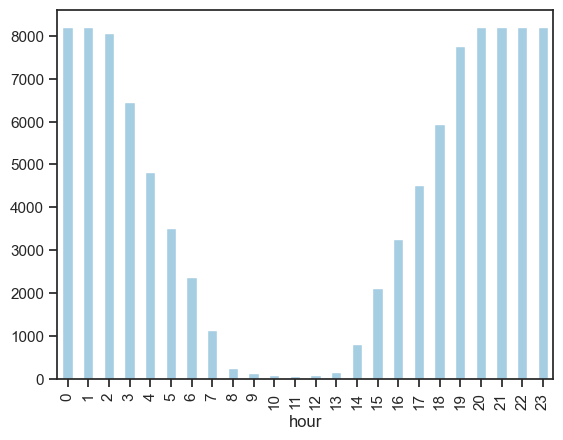

In [11]:
df['hour'][df[target] == 0].value_counts().sort_index().plot(kind='bar')

야간에 발전량이 0인 데이터가 집중되어있어 정상데이터로 판단되나, 낮에 0인 데이터가 일부 존재해 구름 유무 및 오류의 가능성을 검토해볼 필요가 있어보임

<Axes: xlabel='Energy_Delta', ylabel='Count'>

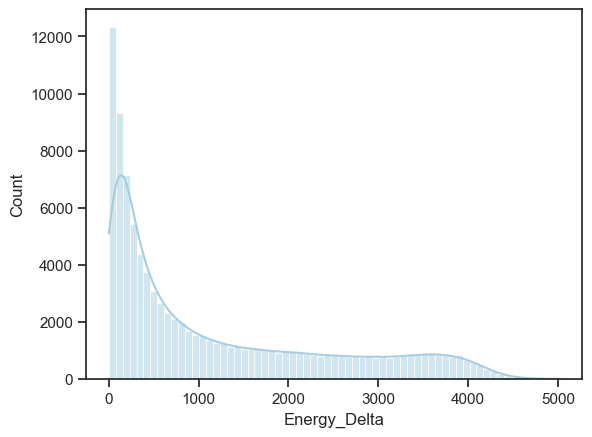

In [12]:
sns.histplot(data=df[df[target]!=0], x=target, kde=True)

대부분의 발전량이 1000보다 적은 구간에 집중되어있음. 기상환경에 영향을 크게 받는 태양광 발전량 데이터의 전형적인 특징을 나타내고 있음.

In [13]:
features = df.columns.tolist()
features.remove(target)
features

['Time',
 'GHI',
 'temp',
 'pressure',
 'humidity',
 'wind_speed',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'isSun',
 'sunlightTime',
 'dayLength',
 'SunlightTime/daylength',
 'weather_type',
 'hour',
 'month']

In [14]:
df['isSun'] = df['isSun'].astype('object')
df['weather_type'] = df['weather_type'].astype('object')
df['hour'] = df['hour'].astype('object')
df['month'] = df['month'].astype('object')

태양 유무와 날씨 타입은 숫자에 의미가 있는 것이 아닌 숫자를 하나의 분류 레이블로써 사용하기 위해 int에서 object 타입으로 변환. hour와 month도 int로 사용하면 23과 0은 숫자로 볼 때 먼 거리이지만 실제로는 가깝다는 것을 학습시키기 위해 object 타입으로 변경

In [15]:
cat_cols = []
num_cols = []

for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        num_cols.append(column)
    elif pd.api.types.is_object_dtype(df[column]):
        cat_cols.append(column)
        
print(f'Categorical columns: {len(cat_cols)}', cat_cols)
print(f'Numeric columns: {len(num_cols)}', num_cols)

Categorical columns: 5 ['Time', 'isSun', 'weather_type', 'hour', 'month']
Numeric columns: 12 ['Energy_Delta', 'GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'sunlightTime', 'dayLength', 'SunlightTime/daylength']


범주형 데이터와 수치형 데이터 컬럼을 각각 다른 리스트로 묶음.

In [16]:
df[df[target]!=0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 95926 entries, 32 to 196774
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Time                    95926 non-null  object 
 1   Energy_Delta            95926 non-null  int64  
 2   GHI                     95926 non-null  float64
 3   temp                    95926 non-null  float64
 4   pressure                95926 non-null  int64  
 5   humidity                95926 non-null  int64  
 6   wind_speed              95926 non-null  float64
 7   rain_1h                 95926 non-null  float64
 8   snow_1h                 95926 non-null  float64
 9   clouds_all              95926 non-null  int64  
 10  isSun                   95926 non-null  object 
 11  sunlightTime            95926 non-null  int64  
 12  dayLength               95926 non-null  int64  
 13  SunlightTime/daylength  95926 non-null  float64
 14  weather_type            95926 non-null  o

#### 카테고리 범주 시각화

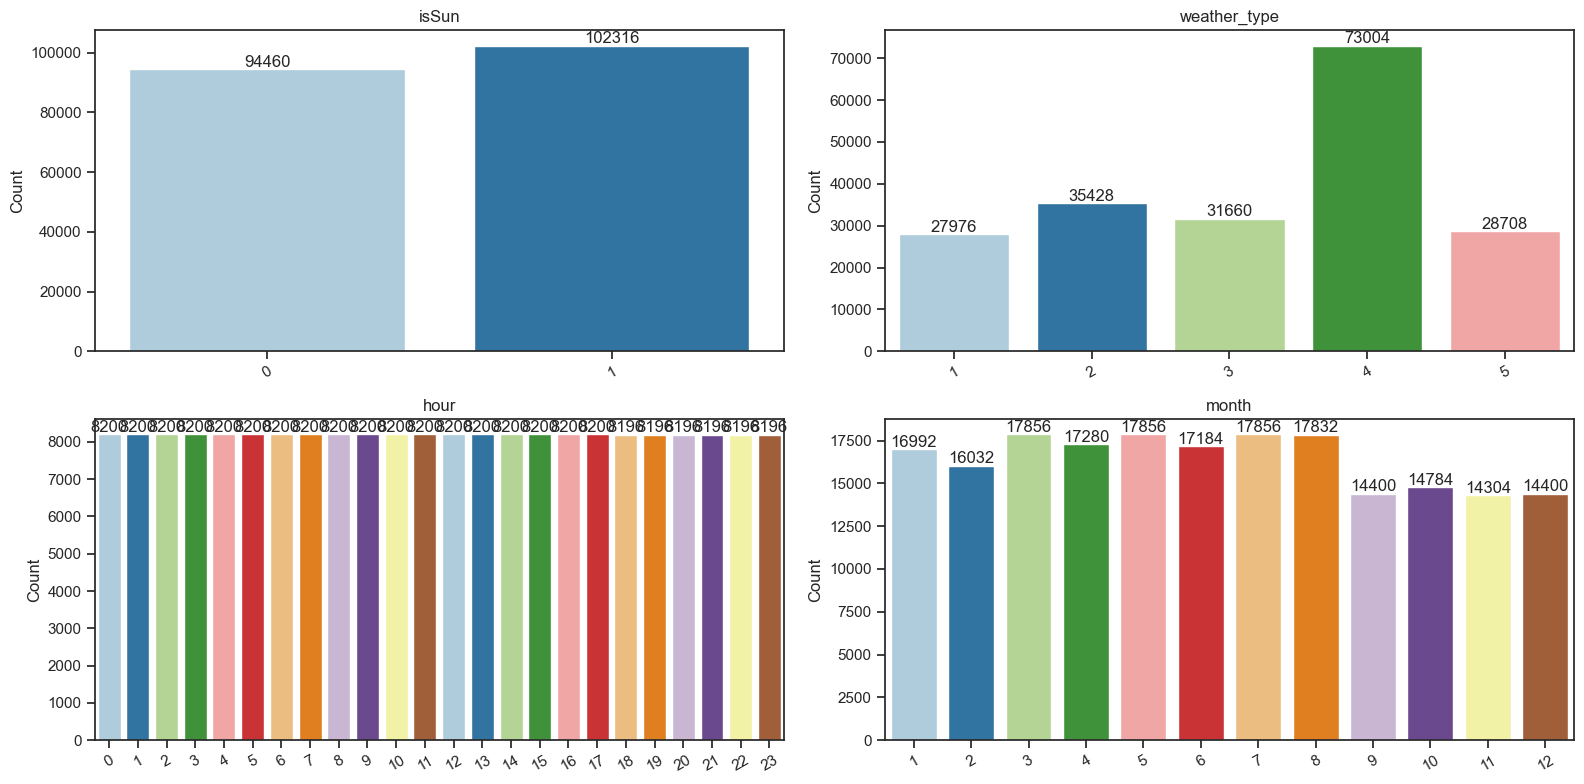

In [17]:
def plot_counts(data, features, hue=None):
    n_cols = 2 
    n_rows = int(np.ceil(len(features)/n_cols)) 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        sns.countplot(
            data = data,
            x = feature,
            palette = 'Paired',
            hue = hue,
            ax = axes[i]
        )
        for p in axes[i].patches:
            label = p.get_height()
            x = p.get_x() + p.get_width() / 2 
            y = p.get_height() 
            
            rotation = 0
            if hue is not None:
                rotation = 30  

            axes[i].annotate(
                '{:.0f}'.format(label),
                (x, y),
                ha = 'center',
                va = 'center',
                size = 12,
                xytext = (0, 5),
                textcoords = 'offset points',
                rotation = rotation
            )
            
        axes[i].set(ylabel='Count', title=feature, xlabel='')
        axes[i].tick_params(axis='x', rotation=30)

    if len(features) % 2 != 0:
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.savefig('0.png', dpi=350, bbox_inches='tight')
    plt.show()

plot_counts(df, cat_cols[1:])

시간을 제외하고 범주형 카테고리의 종류에 따른 빈도를 시각화. 범주의 데이터 분포 균형을 파악하고, feature engineering 전략을 수립하기 위한 시각화
날씨 중에 4번의 날씨가 많은 날씨 특성을 보유하고 있음.

#### 수치형 범주 시각화

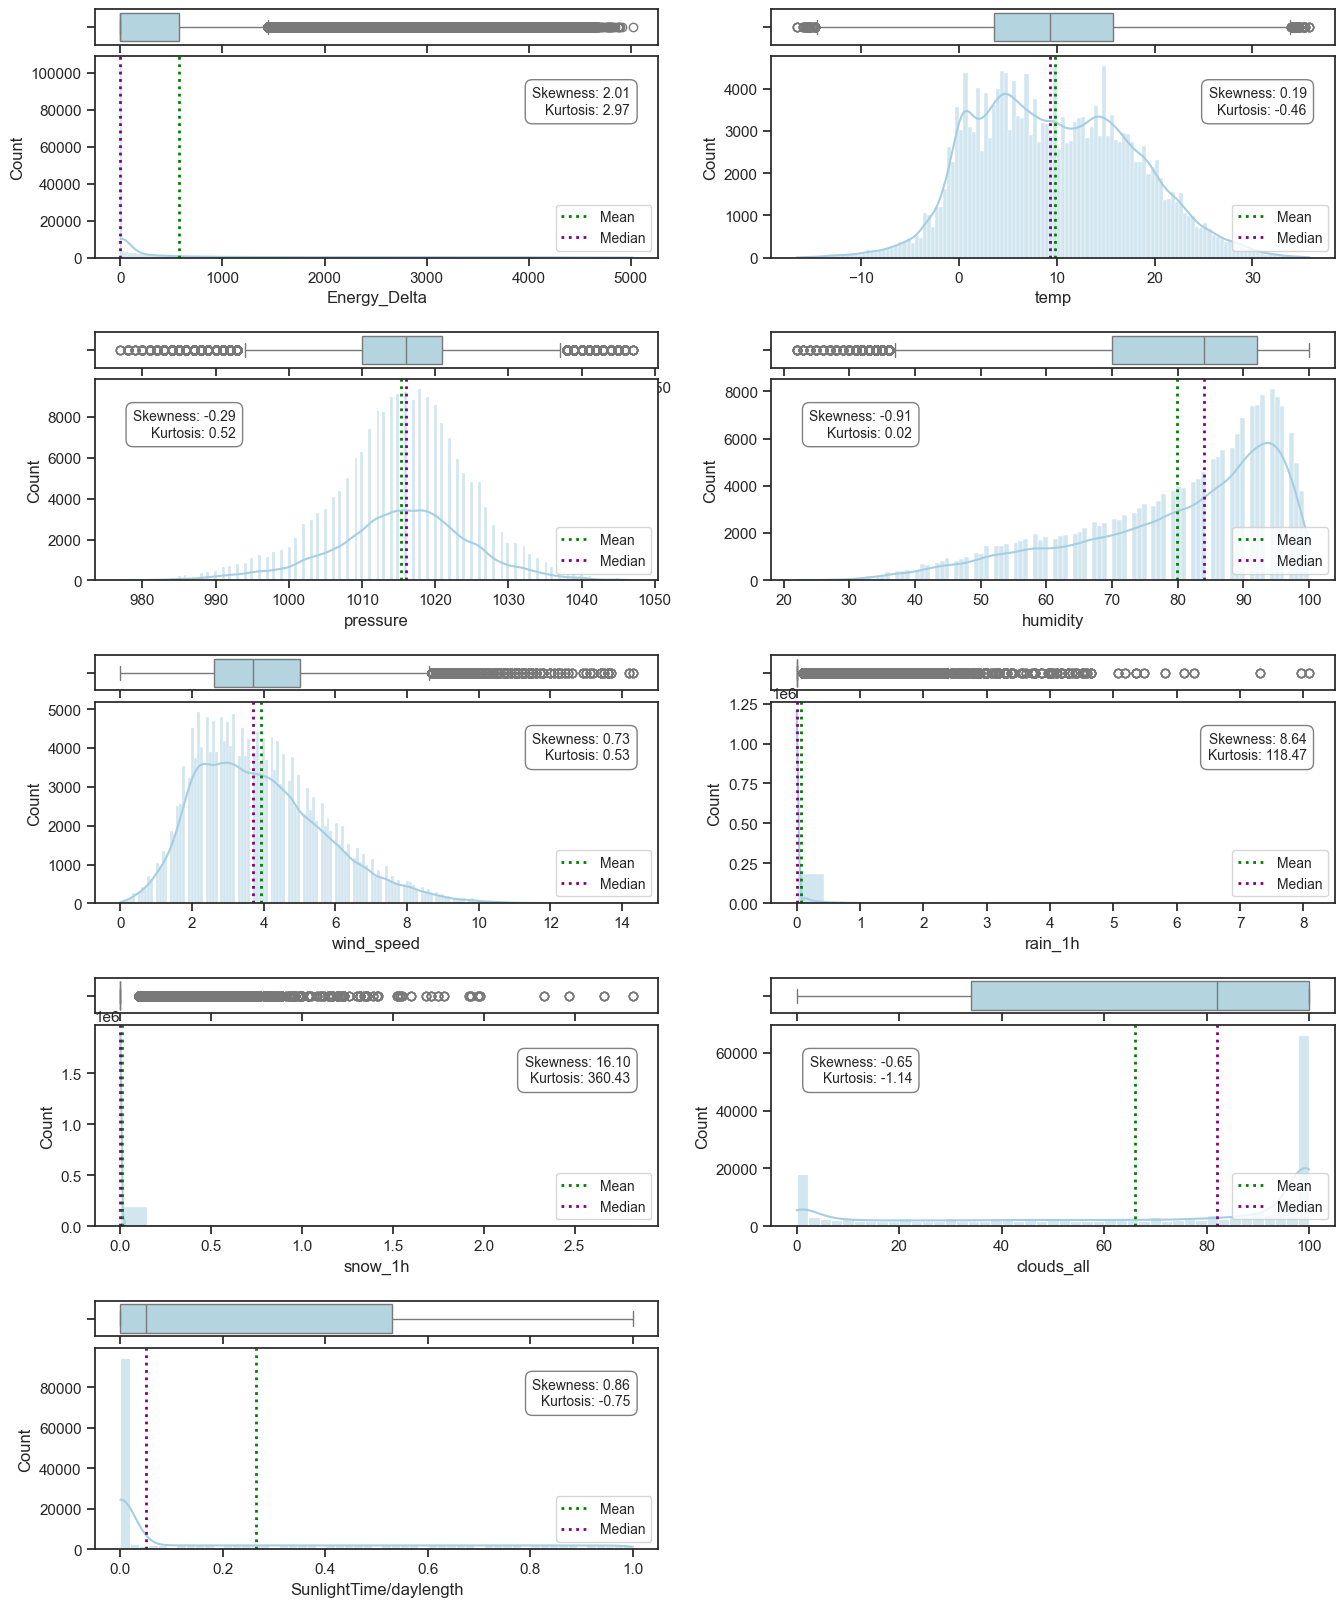

In [39]:
def dist_plot(data, feature_list):
    n_cols = 2 
    n_rows = int(np.ceil(len(feature_list)/n_cols)) 

    fig = plt.figure(figsize=(16, 4*n_rows))
    outer = gridspec.GridSpec(n_rows, n_cols, wspace=0.2, hspace=0.3)

    for i in range(len(feature_list)):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], 
                                                 wspace=0.1, hspace=0.1, height_ratios=(0.15, 0.85))

        ax_box = plt.Subplot(fig, inner[0])
        sns.boxplot(data=data, x=feature_list[i], color='lightblue', ax=ax_box)
        ax_box.set_xlabel('')
        fig.add_subplot(ax_box)

        mean_value = data[feature_list[i]].mean()
        median_value = data[feature_list[i]].median()
        ax_hist = plt.Subplot(fig, inner[1])
        sns.histplot(data=data, x=feature_list[i], kde=True, ax=ax_hist)
        ax_hist.axvline(mean_value, color='green', linestyle='dotted', linewidth=2, label='Mean')
        ax_hist.axvline(median_value, color='purple', linestyle='dotted', linewidth=2, label='Median')
        # Add a legend
        ax_hist.legend(loc='lower right', fontsize=10)

        skewness = data[feature_list[i]].skew()
        kurt = data[feature_list[i]].kurt()
        if skewness < 0:
            x=0.25
        else:
            x=0.95
        ax_hist.text(x, 0.85, f"Skewness: {skewness:.2f}\nKurtosis: {kurt:.2f}", 
                         transform=ax_hist.transAxes, verticalalignment='top', horizontalalignment='right',
                         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'),
                    fontsize=10)
        fig.add_subplot(ax_hist)

    plt.tight_layout()
    plt.savefig('1.png', dpi=350, bbox_inches='tight')
    plt.show(block=False)

dist_plot(df, num_cols)

분포 분석 결과, 타겟 변수 및 핵심 특징의 극심한 비대칭성을 확인. 전처리 과정에서 로그 변환을 수행하여, 모델이 데이터를 더 안정적으로 학습할 수 있는 환경을 마련

#### 이변량 분석 시각화
- 두 개의 변수(Variable) 간의 관계를 탐색하고 이해 하기 위해 진행

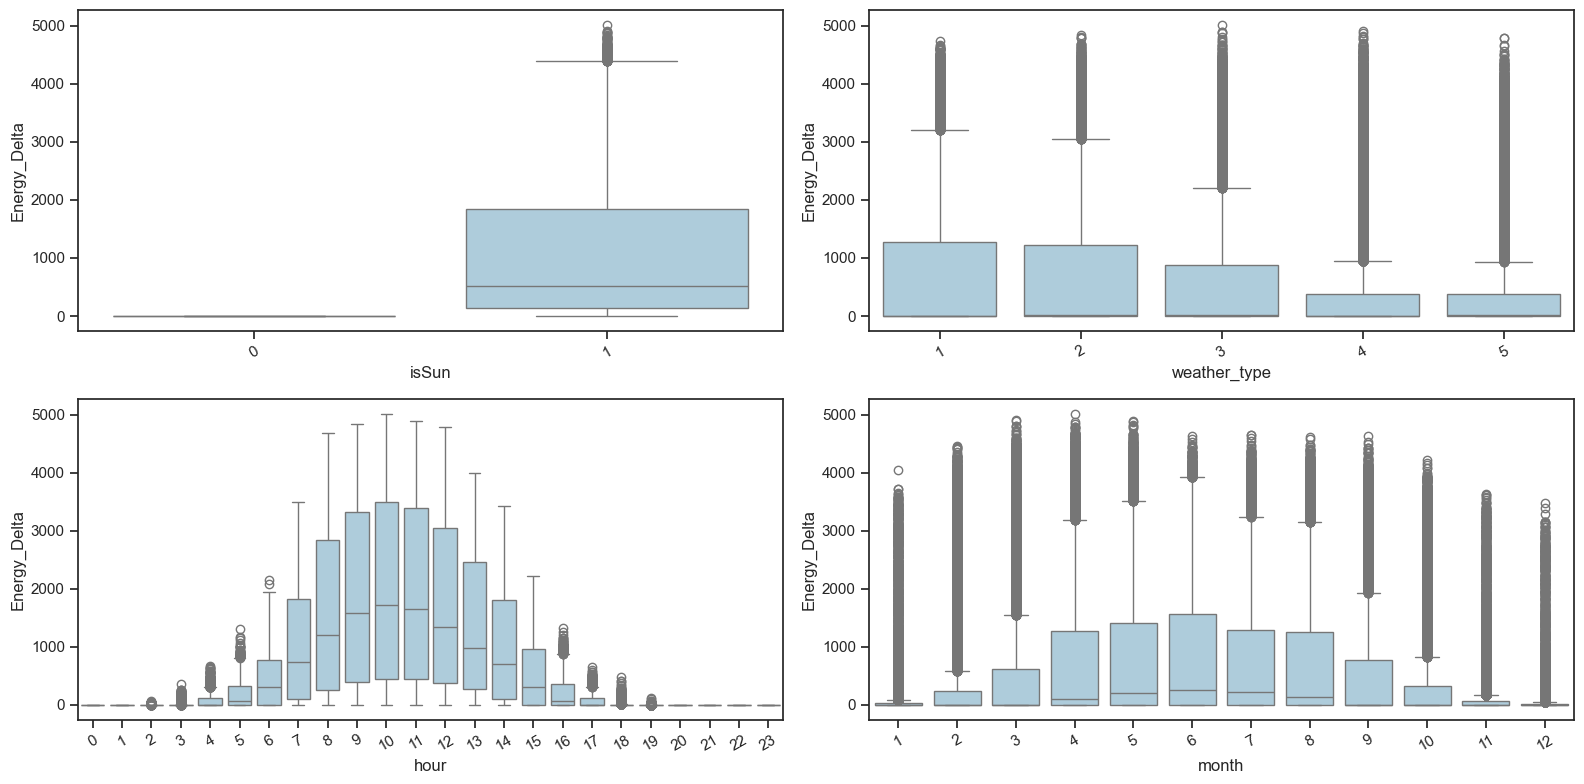

In [20]:
n_cols = 2 
n_rows = int(np.ceil(len(cat_cols[1:])/n_cols)) 

fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
ax = ax.flatten()
    
for i, feature in enumerate(cat_cols[1:]):
    sns.boxplot(data=df, x=feature, y=target, ax=ax[i])
    ax[i].tick_params(axis='x', rotation=30)

if len(cat_cols[1:]) % 2 != 0:
    fig.delaxes(ax[-1])
    
plt.tight_layout()
plt.savefig('2.png', dpi=350, bbox_inches='tight')
plt.show(block=False)

#### 다변량 분석

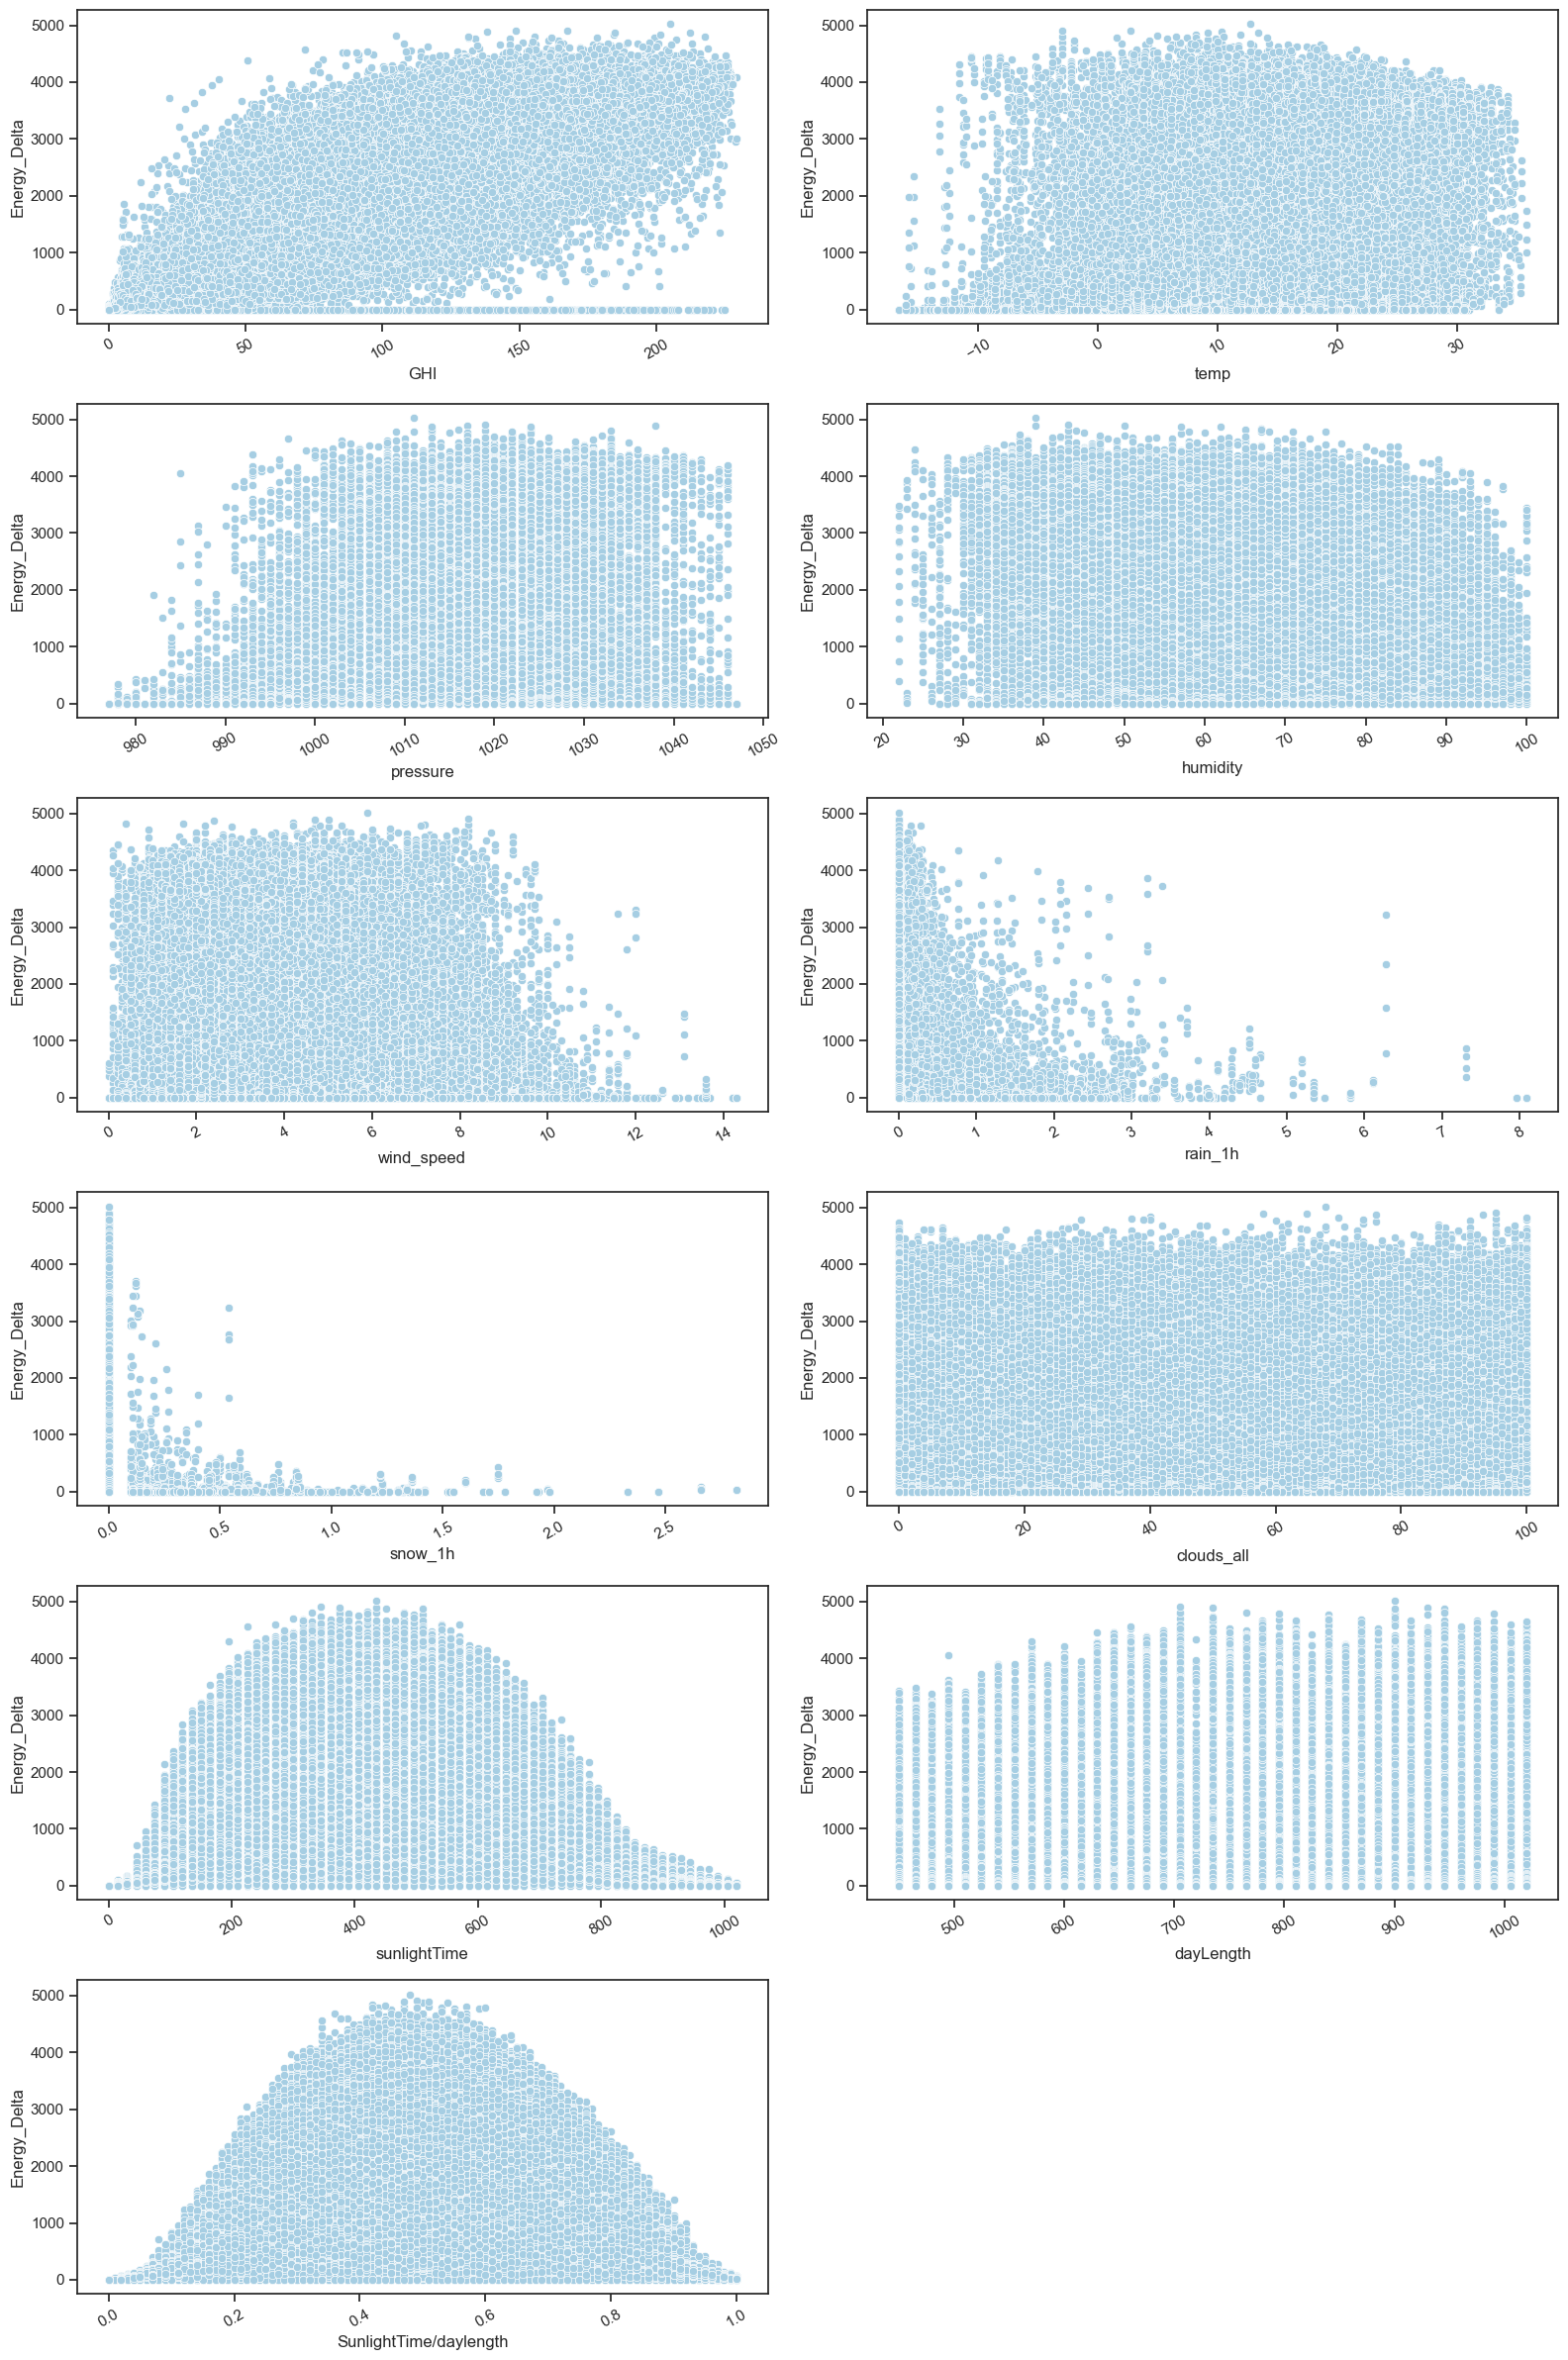

In [24]:
n_cols = 2 
n_rows = int(np.ceil(len(num_cols[1:])/n_cols)) 

fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
ax = ax.flatten()
    
for i, feature in enumerate(num_cols[1:]):
    sns.scatterplot(data=df, x=feature, y=target, ax=ax[i], palette='flare')
    ax[i].tick_params(axis='x', rotation=30)
if len(num_cols[1:]) % 2 != 0:
    fig.delaxes(ax[-1])
    
plt.tight_layout()
plt.savefig('3.png', dpi=350, bbox_inches='tight')
plt.show(block=False)

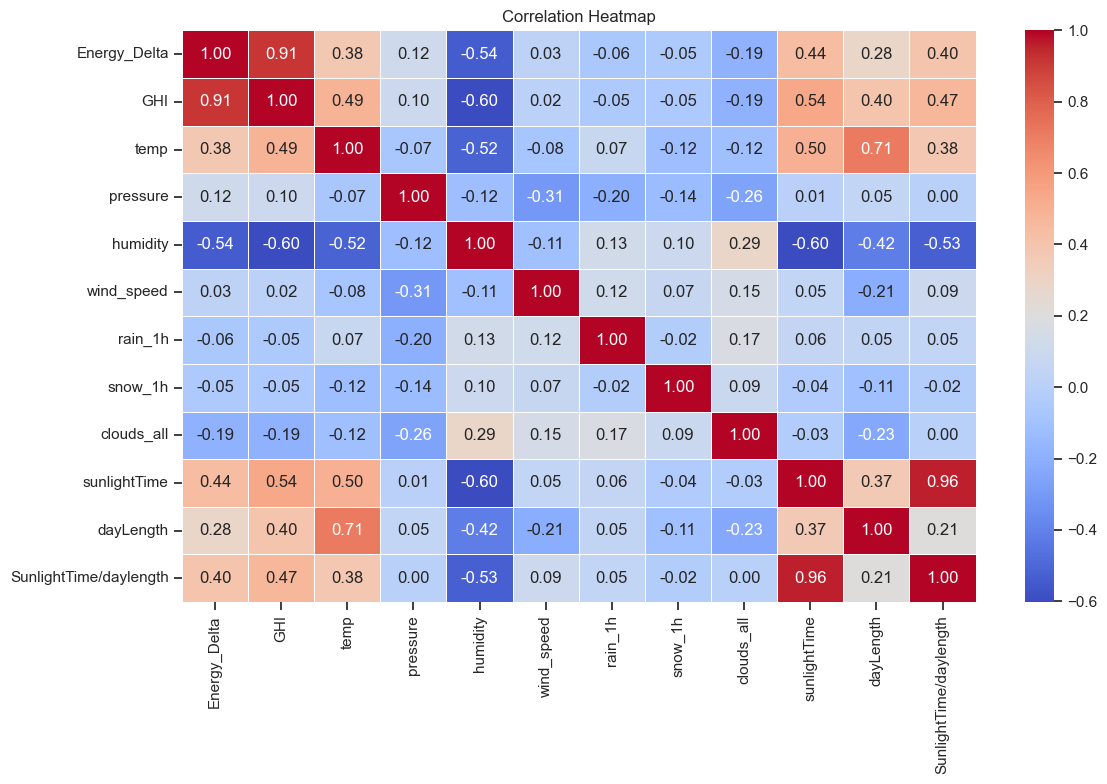

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.drop(cat_cols, axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('4.png', dpi=350, bbox_inches='tight')
plt.show()

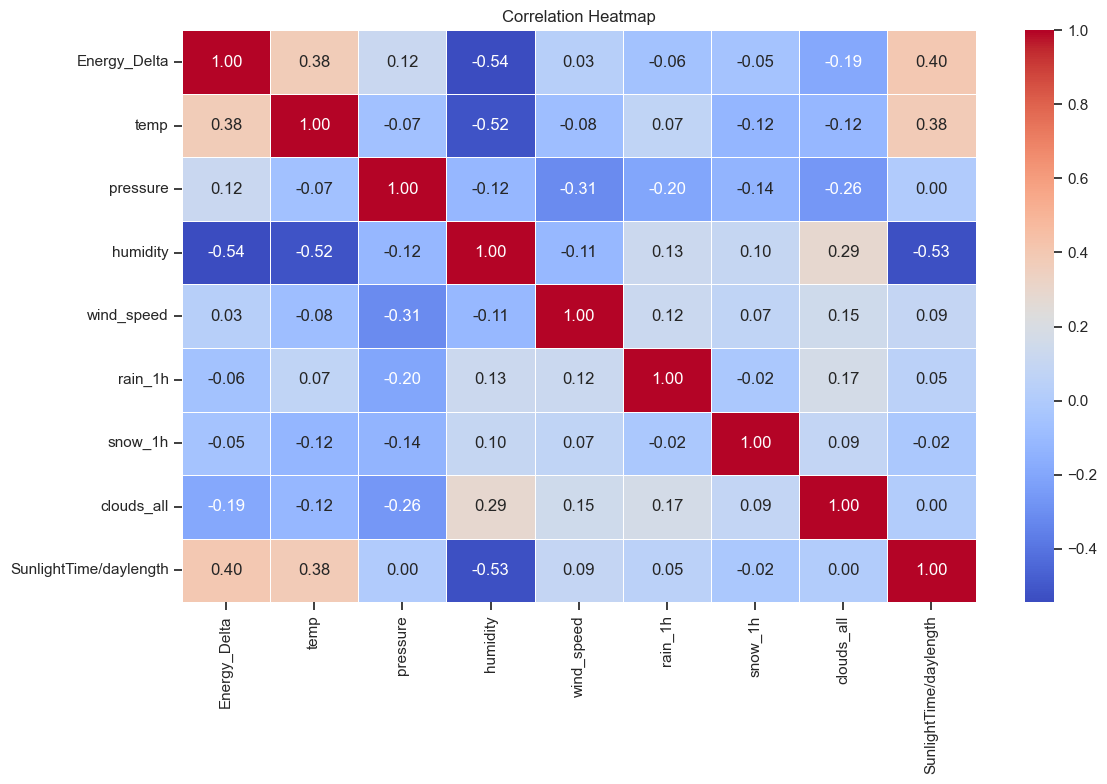

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.drop(cat_cols + ['GHI', 'sunlightTime', 'dayLength'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('5.png', dpi=350, bbox_inches='tight')
plt.show()

## 데이터 전처리

In [27]:
df_non_zero = df[df[target]!=0]
df_non_zero.reset_index(drop=True, inplace=True)
df_non_zero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95926 entries, 0 to 95925
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Time                    95926 non-null  object 
 1   Energy_Delta            95926 non-null  int64  
 2   GHI                     95926 non-null  float64
 3   temp                    95926 non-null  float64
 4   pressure                95926 non-null  int64  
 5   humidity                95926 non-null  int64  
 6   wind_speed              95926 non-null  float64
 7   rain_1h                 95926 non-null  float64
 8   snow_1h                 95926 non-null  float64
 9   clouds_all              95926 non-null  int64  
 10  isSun                   95926 non-null  object 
 11  sunlightTime            95926 non-null  int64  
 12  dayLength               95926 non-null  int64  
 13  SunlightTime/daylength  95926 non-null  float64
 14  weather_type            95926 non-null

발전량이 0보다 클때의 행만 추출한 갯수. (전체 196776행)

In [29]:
df_non_zero.drop(['Time', 'GHI', 'sunlightTime', 'dayLength', 'isSun'], axis=1, inplace=True)
df_non_zero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95926 entries, 0 to 95925
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Energy_Delta            95926 non-null  int64  
 1   temp                    95926 non-null  float64
 2   pressure                95926 non-null  int64  
 3   humidity                95926 non-null  int64  
 4   wind_speed              95926 non-null  float64
 5   rain_1h                 95926 non-null  float64
 6   snow_1h                 95926 non-null  float64
 7   clouds_all              95926 non-null  int64  
 8   SunlightTime/daylength  95926 non-null  float64
 9   weather_type            95926 non-null  object 
 10  hour                    95926 non-null  object 
 11  month                   95926 non-null  object 
dtypes: float64(5), int64(4), object(3)
memory usage: 8.8+ MB


- 0 값이 아닌 행에서 Time, GHI, sunlightTime, dayLength, isSun 열을 탈락시킴.
- GHI는 현실적으로 얻기 어려운 데이터여서 탈락
- 나머지 sunlightTime, dayLength, isSun은 열 간의 상관관계가 매우 높게 나타나서 삭제하는 대신, sunlightTime은 발전량에 높은 상관관계를 가지므로, sunlightTime/dayLength라는 새로운 feature를 만들어서 학습에 사용
- Time은 왜 삭제했을까? -->

In [30]:
df_non_zero.nunique()

Energy_Delta              4555
temp                       476
pressure                    69
humidity                    79
wind_speed                 121
rain_1h                    288
snow_1h                     89
clouds_all                 101
SunlightTime/daylength     100
weather_type                 5
hour                        18
month                       12
dtype: int64

발전량이 0보다 클때 서로 중복되지 않는 값의 갯수

In [31]:
cat_cols = []
num_cols = []

for column in df_non_zero.columns:
    if pd.api.types.is_numeric_dtype(df_non_zero[column]):
        num_cols.append(column)
    elif pd.api.types.is_object_dtype(df_non_zero[column]):
        cat_cols.append(column)
        
print(f'Categorical columns: {len(cat_cols)}', cat_cols)
print(f'Numeric columns: {len(num_cols)}', num_cols)

Categorical columns: 3 ['weather_type', 'hour', 'month']
Numeric columns: 9 ['Energy_Delta', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'SunlightTime/daylength']


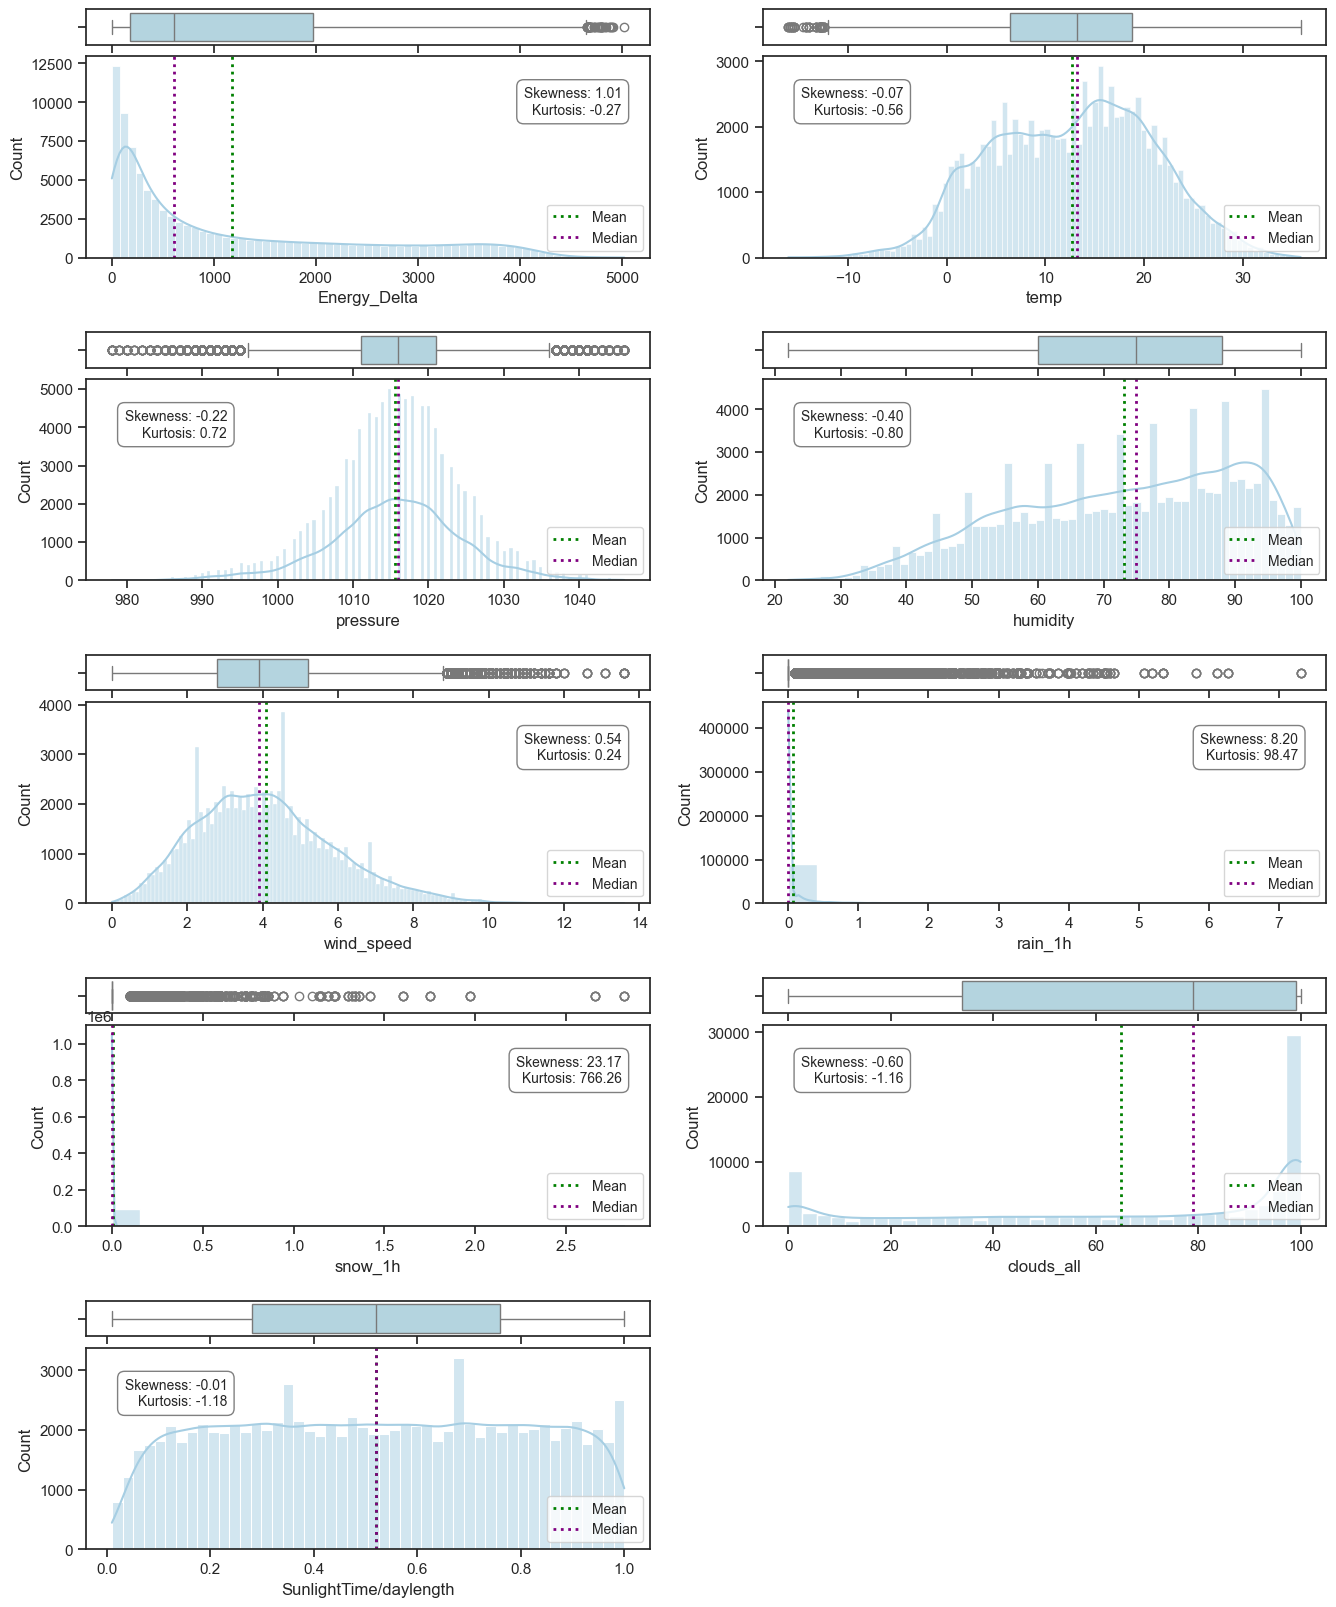

In [48]:
def dist_plot(data, feature_list):
    n_cols = 2 
    n_rows = int(np.ceil(len(feature_list)/n_cols)) 

    fig = plt.figure(figsize=(16, 4*n_rows))
    outer = gridspec.GridSpec(n_rows, n_cols, wspace=0.2, hspace=0.3)

    for i in range(len(feature_list)):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], 
                                                 wspace=0.1, hspace=0.1, height_ratios=(0.15, 0.85))

        ax_box = plt.Subplot(fig, inner[0])
        sns.boxplot(data=data, x=feature_list[i], color='lightblue', ax=ax_box)
        ax_box.set_xlabel('')
        fig.add_subplot(ax_box)

        mean_value = data[feature_list[i]].mean()
        median_value = data[feature_list[i]].median()
        ax_hist = plt.Subplot(fig, inner[1])
        sns.histplot(data=data, x=feature_list[i], kde=True, ax=ax_hist)
        ax_hist.axvline(mean_value, color='green', linestyle='dotted', linewidth=2, label='Mean')
        ax_hist.axvline(median_value, color='purple', linestyle='dotted', linewidth=2, label='Median')
        # Add a legend
        ax_hist.legend(loc='lower right', fontsize=10)

        skewness = data[feature_list[i]].skew()
        kurt = data[feature_list[i]].kurt()
        if skewness < 0:
            x=0.25
        else:
            x=0.95
        ax_hist.text(x, 0.85, f"Skewness: {skewness:.2f}\nKurtosis: {kurt:.2f}", 
                         transform=ax_hist.transAxes, verticalalignment='top', horizontalalignment='right',
                         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'),
                    fontsize=10)
        fig.add_subplot(ax_hist)

    plt.tight_layout()
    plt.savefig('6.png', dpi=350, bbox_inches='tight')
    plt.show(block=False)

dist_plot(df_non_zero, num_cols)

In [33]:
df_non_zero[df_non_zero['rain_1h']!=0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 13694 entries, 39 to 95898
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Energy_Delta            13694 non-null  int64  
 1   temp                    13694 non-null  float64
 2   pressure                13694 non-null  int64  
 3   humidity                13694 non-null  int64  
 4   wind_speed              13694 non-null  float64
 5   rain_1h                 13694 non-null  float64
 6   snow_1h                 13694 non-null  float64
 7   clouds_all              13694 non-null  int64  
 8   SunlightTime/daylength  13694 non-null  float64
 9   weather_type            13694 non-null  object 
 10  hour                    13694 non-null  object 
 11  month                   13694 non-null  object 
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [34]:
df_non_zero['rain_1h'][df_non_zero['rain_1h']>0].describe()

count   13694.000
mean        0.515
std         0.644
min         0.100
25%         0.160
50%         0.270
75%         0.600
max         7.310
Name: rain_1h, dtype: float64

In [35]:
df_non_zero[df_non_zero['snow_1h']!=0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1051 entries, 58 to 87025
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Energy_Delta            1051 non-null   int64  
 1   temp                    1051 non-null   float64
 2   pressure                1051 non-null   int64  
 3   humidity                1051 non-null   int64  
 4   wind_speed              1051 non-null   float64
 5   rain_1h                 1051 non-null   float64
 6   snow_1h                 1051 non-null   float64
 7   clouds_all              1051 non-null   int64  
 8   SunlightTime/daylength  1051 non-null   float64
 9   weather_type            1051 non-null   object 
 10  hour                    1051 non-null   object 
 11  month                   1051 non-null   object 
dtypes: float64(5), int64(4), object(3)
memory usage: 106.7+ KB


In [36]:
df_non_zero['snow_1h'][df_non_zero['snow_1h']>0].describe()

count   1051.000
mean       0.387
std        0.372
min        0.100
25%        0.150
50%        0.270
75%        0.480
max        2.820
Name: snow_1h, dtype: float64

- 강수량과 적설량은 다른 데이터에 비해 큰 값이 아님.
- 우선 학습을 진행하고 추후에 0,1로 매핑하여 학습 진행해서 복잡도 및 노이즈 제거해서 성능 비교 할 필요 있음

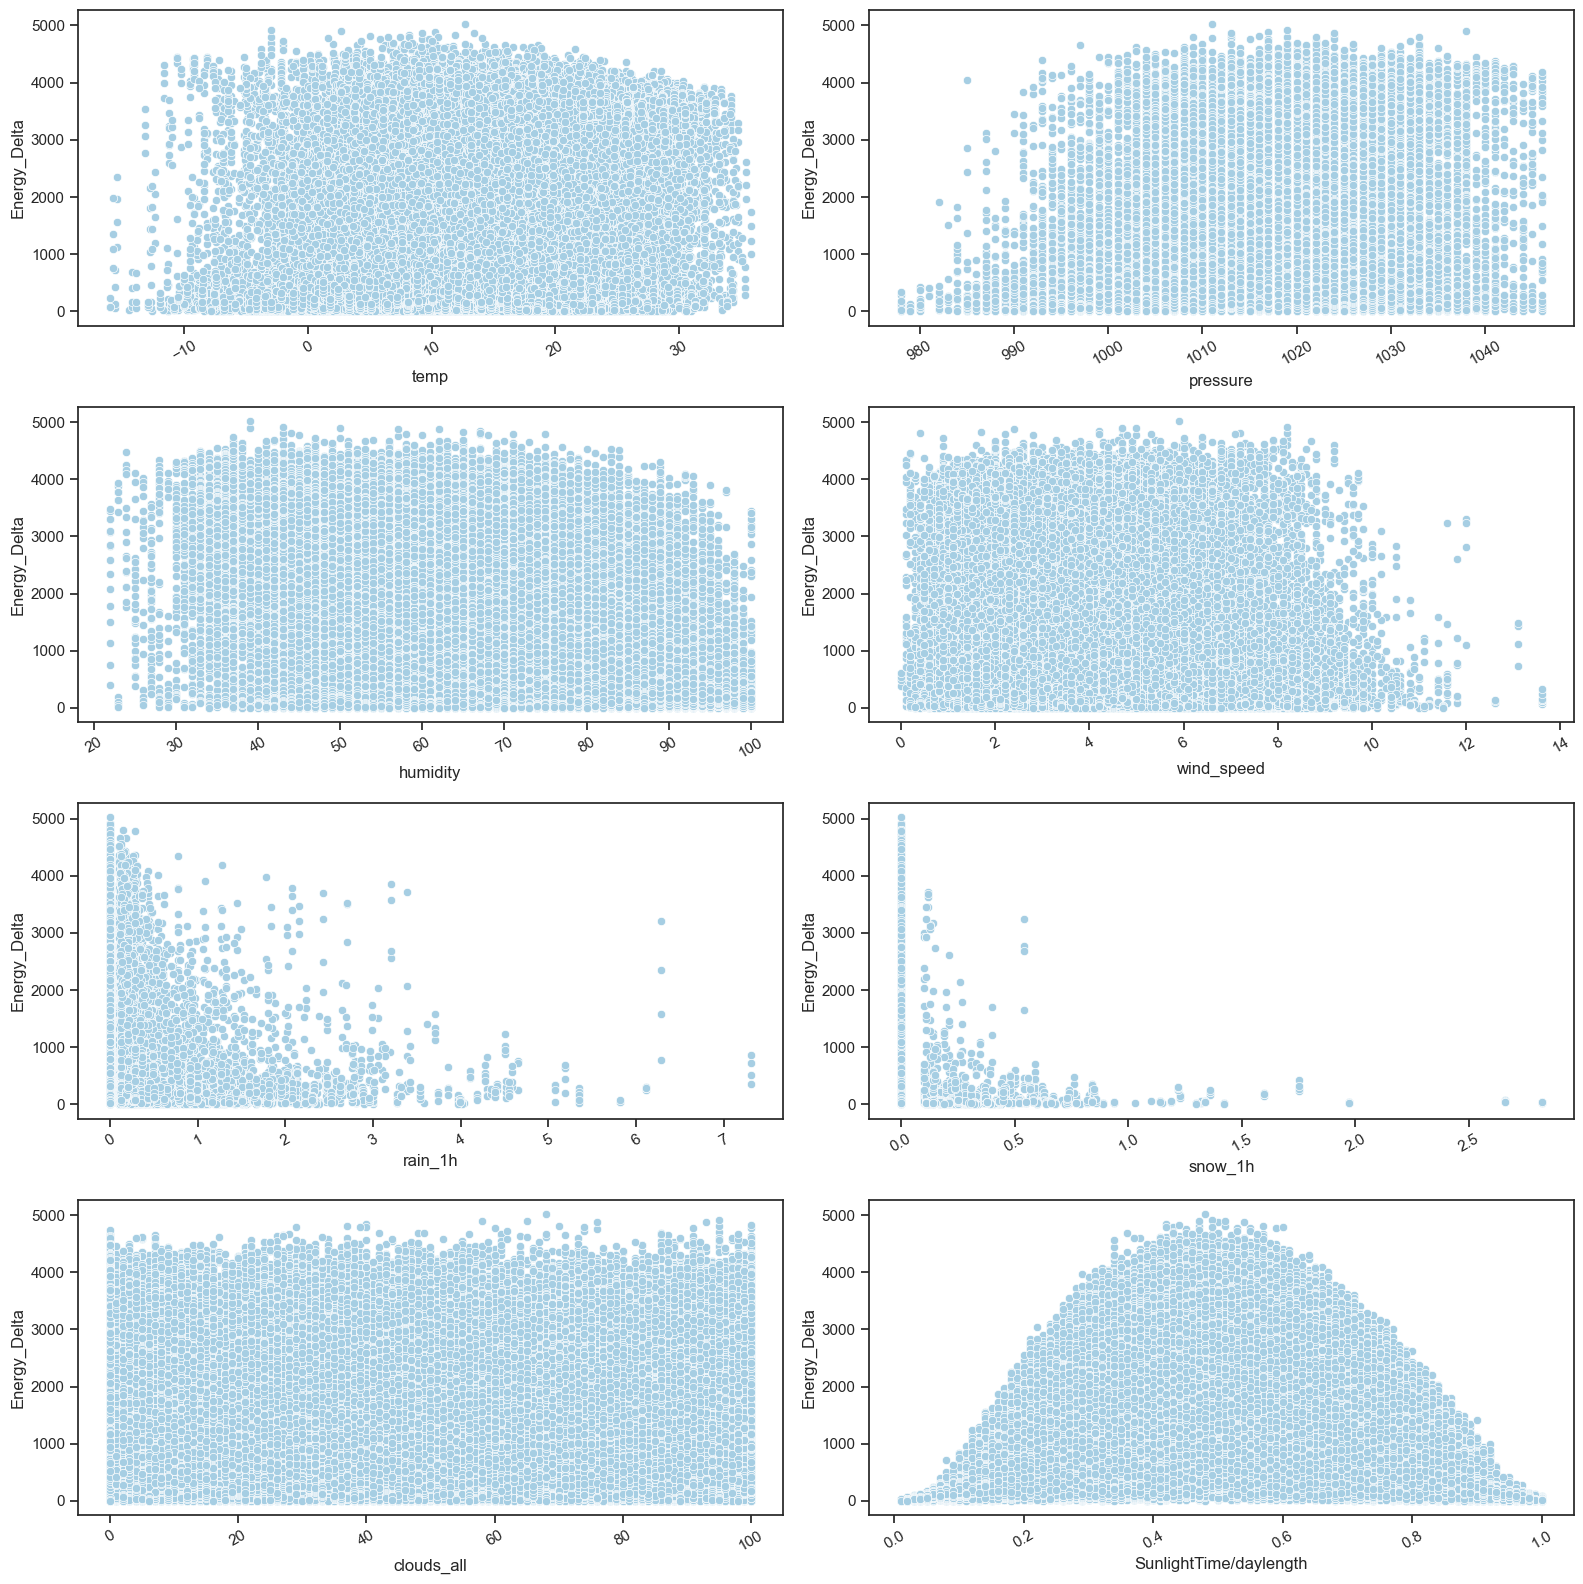

In [41]:
n_cols = 2 
n_rows = int(np.ceil(len(num_cols[1:])/n_cols)) 

fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
ax = ax.flatten()
    
for i, feature in enumerate(num_cols[1:]):
    sns.scatterplot(data=df_non_zero, x=feature, y=target, ax=ax[i], palette='flare')
    ax[i].tick_params(axis='x', rotation=30)
if len(num_cols[1:]) % 2 != 0:
    fig.delaxes(ax[-1])
    
plt.tight_layout()
plt.savefig('7.png', dpi=350, bbox_inches='tight')
plt.show(block=False)

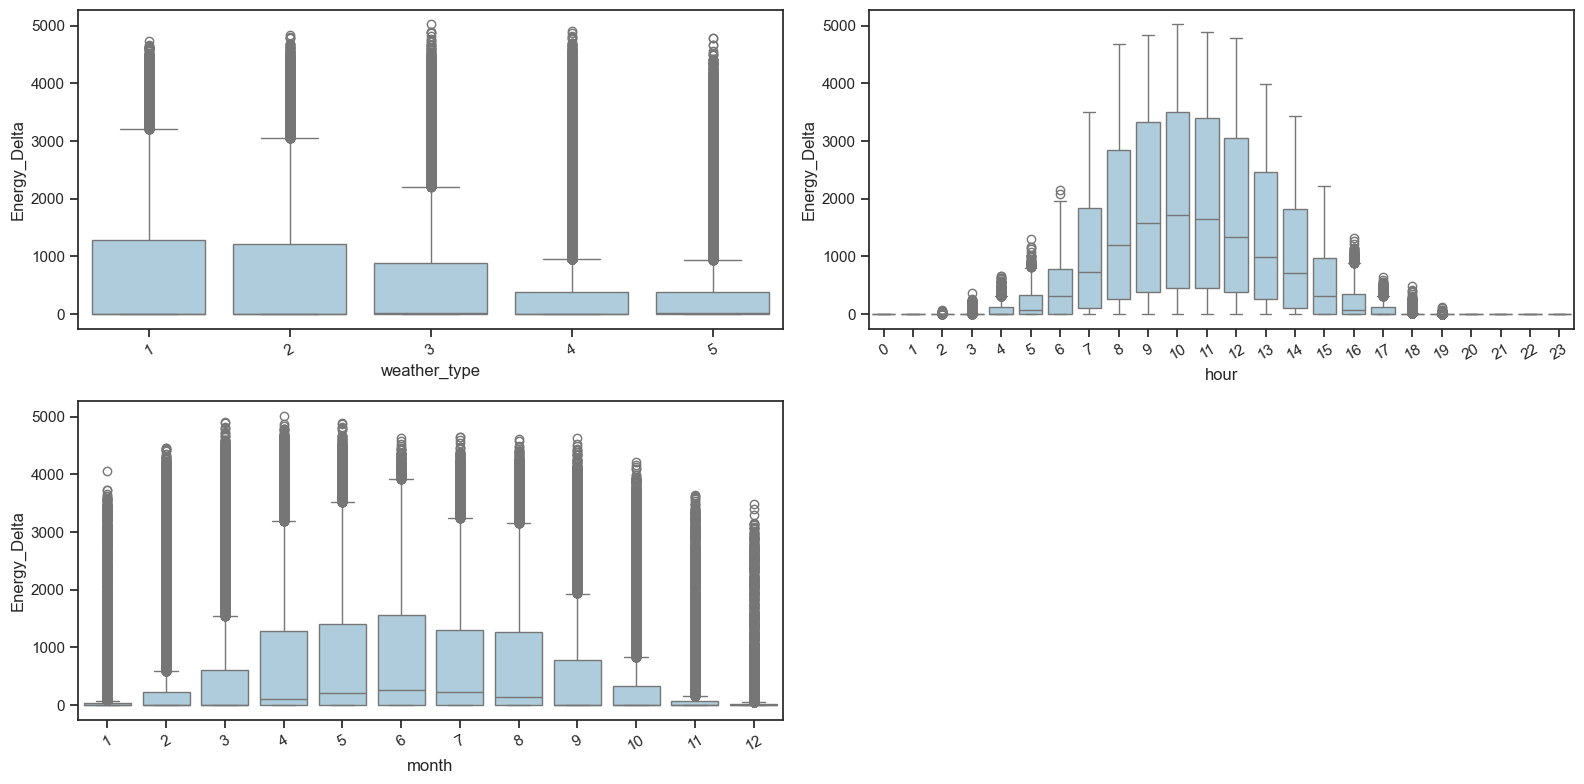

In [43]:
n_cols = 2 
n_rows = int(np.ceil(len(cat_cols)/n_cols)) 

fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
ax = ax.flatten()
    
for i, feature in enumerate(cat_cols):
    sns.boxplot(data=df, x=feature, y=target, ax=ax[i])
    ax[i].tick_params(axis='x', rotation=30)
if len(cat_cols) % 2 != 0:
    fig.delaxes(ax[-1])
    
plt.tight_layout()
plt.savefig('8.png', dpi=350, bbox_inches='tight')
plt.show(block=False)

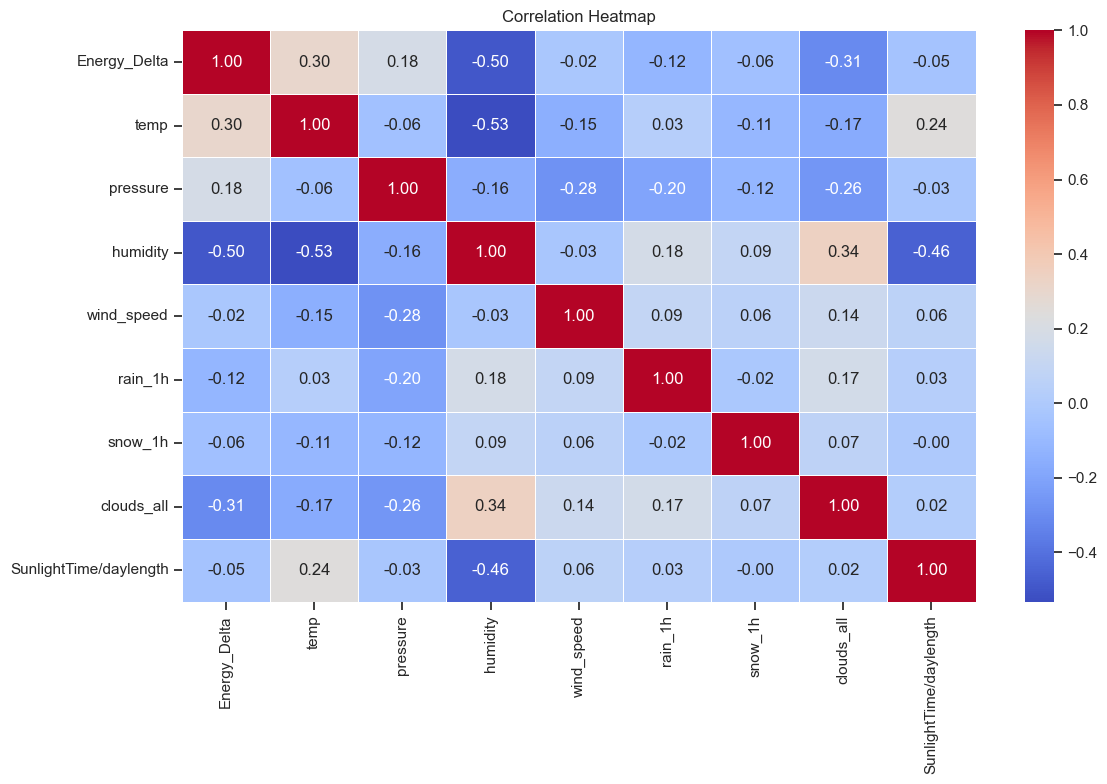

In [45]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_non_zero.drop(cat_cols, axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('9.png', dpi=350, bbox_inches='tight')
plt.show()

### 데이터셋 변환

In [46]:
def transform_data(df, target, num_features, cat_features):

    x = df.drop([target], axis=1)
    y = df[target]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    
    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

    preprocessor = ColumnTransformer([
        ("num", numerical_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ])

    preprocessor.fit(x_train)

    x_train_transformed = preprocessor.transform(x_train)
    x_test_transformed = preprocessor.transform(x_test)
    
    return x_train_transformed, x_test_transformed, y_train, y_test

- 수치형 컬럼은 표준화 변환
- 범주형 컬럼은 원핫 인코딩
- 수치형 컬럼의 0번째 열은 target이므로 1번째 부터 사용
#### ColumnTransformer를 사용하여 학습 데이터셋의 통계로 변환하는 이유:
- 전체 데이터셋으로 테스트 데이터셋을 변환하게 되면 테스트시에는 알 수 없어야 하는 정보
- 예시로, 학습 데이터셋의 표준편차, 평균과 같은 값을 알 수 있게됨.

In [47]:
x_train, x_test, y_train, y_test = transform_data(df_non_zero, target, num_cols[1:], cat_cols)

### 모델링

In [50]:
def model_comparison(x, y, models):
    names = []
    scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']

    df_results = pd.DataFrame(columns=['Algorithm', 'R2 Mean', 'R2 STD', 'RMSE Mean', 'RMSE STD'])
    results_r2 = []
    results_mae = []
    results_rmse = []
    
    for name, model in models:
        names.append(name)
        kfold = KFold(n_splits=10, shuffle=True, random_state=101)
        result = cross_validate(model, x, y, cv=kfold, scoring=scoring)
    
        r2_mean = result['test_r2'].mean()
        r2_std = result['test_r2'].std()

        mae_mean = abs(result['test_neg_mean_absolute_error'].mean())
        mae_std = result['test_neg_mean_absolute_error'].std()
        
        rmse_mean = abs(result['test_neg_root_mean_squared_error'].mean())
        rmse_std = result['test_neg_root_mean_squared_error'].std()
        

        df_result_row = {'Algorithm': name, 'R2 Mean': r2_mean, 'R2 STD': r2_std, 'RMSE Mean': rmse_mean, 
                         'RMSE STD': rmse_std, 'MAE Mean': mae_mean, 'MEA STD': mae_std}
        df_results = pd.concat([df_results, pd.DataFrame([df_result_row])], ignore_index=True)
        results_r2.append(result['test_r2'])
        results_mae.append(abs(result['test_neg_mean_absolute_error']))
        results_rmse.append(abs(result['test_neg_root_mean_squared_error']))

    df_results = df_results.set_index('Algorithm')
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print(df_results)
    
    plot_objects = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
    fig, (ax1, ax2, ax3) = plot_objects
    
    ax1.boxplot(results_r2)
    ax1.set_title('R2', fontsize=14)
    ax1.set_xticklabels(names, rotation=30)
    ax2.boxplot(results_mae)
    ax2.set_title('MAE', fontsize=14)
    ax2.set_xticklabels(names, rotation=30)
    ax3.boxplot(results_rmse)
    ax3.set_title('RMSE', fontsize=14)
    ax3.set_xticklabels(names, rotation=30)
    plt.tight_layout()
    plt.savefig('10.png', dpi=350, bbox_inches='tight')
    plt.show()

#### 앙상블 기법

In [51]:
models_ens = []
models_ens.append(('RFR', RandomForestRegressor()))
models_ens.append(('ADR', AdaBoostRegressor()))
models_ens.append(('GBR', GradientBoostingRegressor()))

           R2 Mean  R2 STD  RMSE Mean  RMSE STD  MAE Mean  MEA STD
Algorithm                                                         
RFR          0.883   0.005    423.248     5.380   253.703    2.544
ADR          0.604   0.010    778.782     9.640   630.887   11.216
GBR          0.756   0.008    610.887     9.918   417.046    7.825


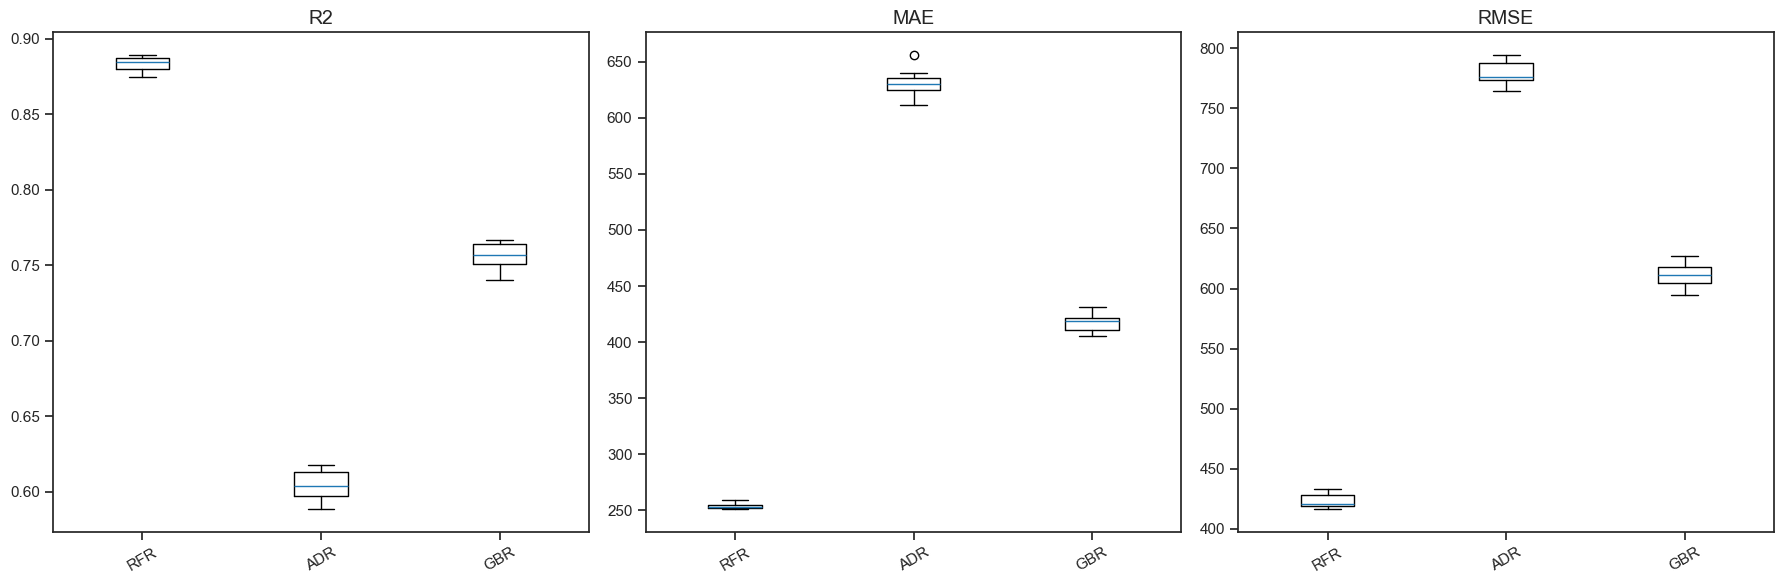

In [52]:
model_comparison(x_train, y_train, models_ens)

#### 비선형 기법

           R2 Mean  R2 STD  RMSE Mean  RMSE STD  MAE Mean  MEA STD
Algorithm                                                         
DTR          0.796   0.007    559.457     7.685   312.249    3.520
KNN          0.803   0.008    549.532     8.563   343.179    5.795
GNB         -0.714   0.067   1619.718    30.268  1228.745   25.938
XBR          0.825   0.006    518.238     7.512   335.968    4.651


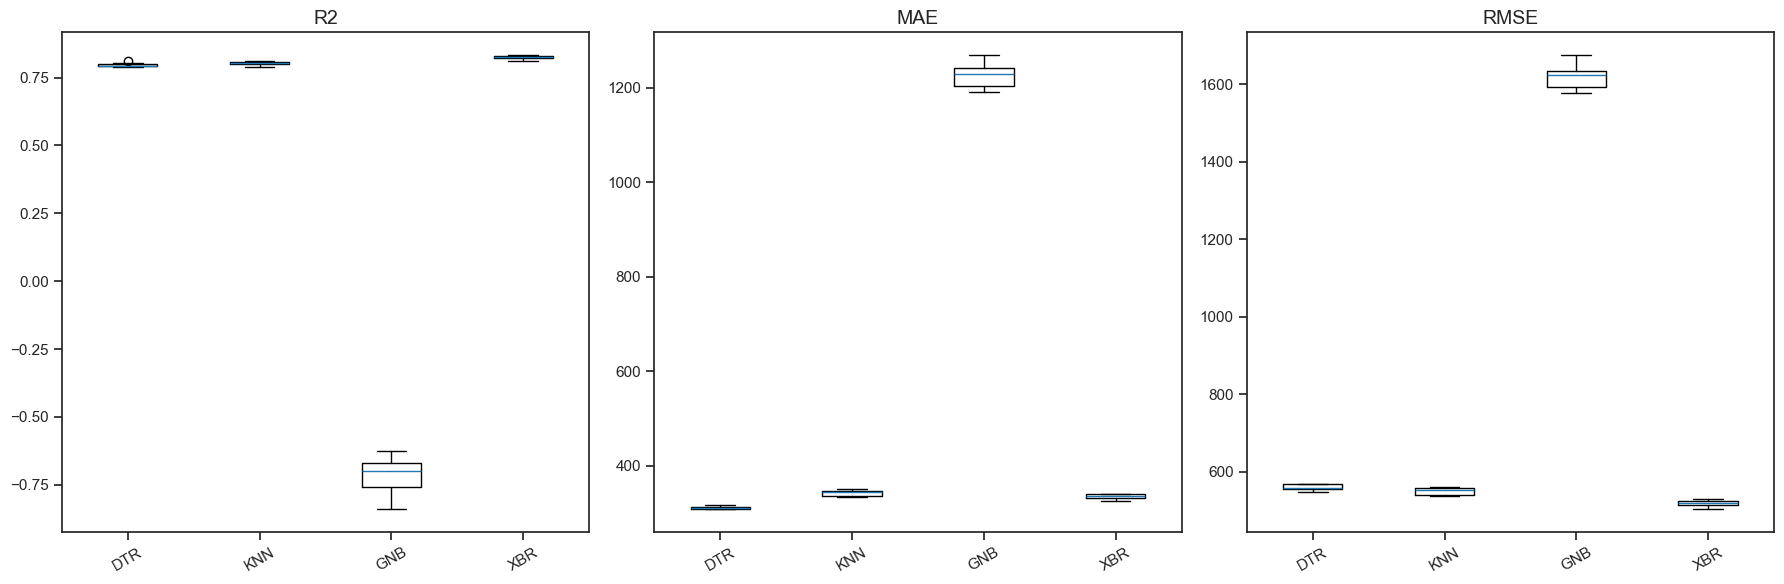

In [54]:
models_nl = []
models_nl.append(('DTR', DecisionTreeRegressor()))
models_nl.append(('KNN', KNeighborsRegressor()))
models_nl.append(('GNB', GaussianNB()))
models_nl.append(('XBR', XGBRegressor()))

model_comparison(x_train, y_train, models_nl)

In [55]:
model_rfr = RandomForestRegressor()
model_rfr.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_hat = model_rfr.predict(x_test)

In [57]:
model_rfr.score(x_test, y_test)

0.8918540029438919

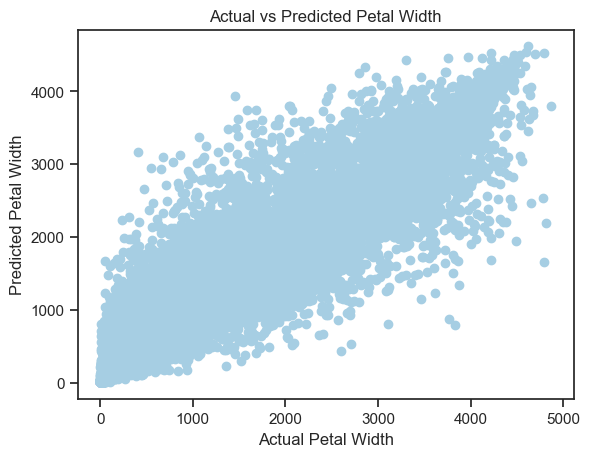

In [58]:
plt.scatter(y_test, y_hat)
plt.xlabel('Actual Petal Width')
plt.ylabel('Predicted Petal Width')
plt.title('Actual vs Predicted Petal Width')
plt.savefig('11.png', dpi=350, bbox_inches='tight')
plt.show()

In [59]:
df_compare = pd.DataFrame(columns=['Targets', 'Predictions'])
df_compare['Targets'] = y_test
df_compare['Predictions'] = y_hat
df_compare['Residuals'] = df_compare['Targets'] - df_compare['Predictions'] 
df_compare['Difference%'] = np.absolute(df_compare['Residuals']/df_compare['Targets']*100) 
df_compare.head()

,Targets,Predictions,Residuals,Difference%
48104,1226,681.170,544.830,44.440
2514,268,1090.400,-822.400,306.866
78865,39,32.500,6.500,16.667
62814,1572,2054.260,-482.260,30.678
26127,2288,1783.700,504.300,22.041


In [60]:
df_compare.sort_values('Difference%', ascending=False).head(10)

,Targets,Predictions,Residuals,Difference%
33730,5,646.420,-641.420,12828.400
95219,7,806.300,-799.300,11418.571
26475,2,217.770,-215.770,10788.500
33731,7,713.300,-706.300,10090.000
83545,2,124.540,-122.540,6127.000
32379,5,305.240,-300.240,6004.800
48136,8,442.450,-434.450,5430.625
9893,2,90.690,-88.690,4434.500
72037,2,89.790,-87.790,4389.500
62619,13,561.870,-548.870,4222.077


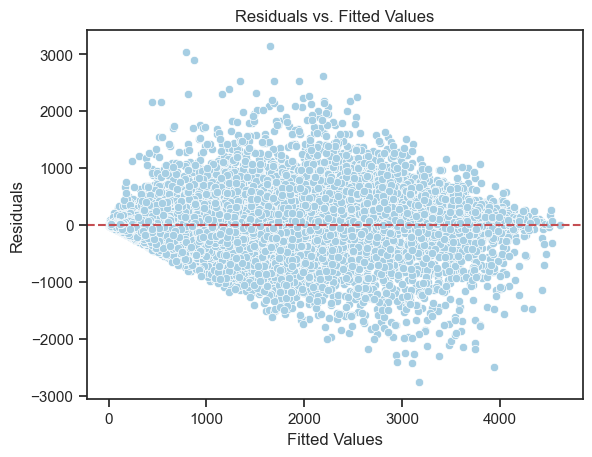

In [61]:
sns.scatterplot(x=df_compare['Predictions'], y=df_compare['Residuals'])
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.savefig('12.png', dpi=350, bbox_inches='tight')
plt.show()